In [12]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, tukey_hsd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

ANOVA ANALYSIS

In [2]:
# Loading main data file
wb = pd.read_csv('../data/world-bank.csv')
wb.head()

,Country Name,Country Code,Region,IsCountry,Income group,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
0,Afghanistan,AFG,South Asia,1,Low income,2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,South Asia,1,Low income,2021,NaN,-2.529855,NaN,1.052,...,4.643,NaN,NaN,NaN,NaN,NaN,NaN,22678024.0,145787.0,NaN
2,Afghanistan,AFG,South Asia,1,Low income,2020,1.5,-2.705030,0.38689,1.052,...,4.750,652230.0,1.852782,NaN,NaN,59.752281,NaN,22678024.0,145787.0,NaN
3,Afghanistan,AFG,South Asia,1,Low income,2019,1.5,-2.655531,NaN,1.053,...,4.870,652230.0,1.852782,NaN,NaN,57.908252,NaN,22580071.0,134636.0,NaN
4,Afghanistan,AFG,South Asia,1,Low income,2018,1.5,-2.763864,0.34523,1.053,...,5.002,652230.0,1.852782,NaN,NaN,56.248231,NaN,21976355.0,127794.0,NaN


In [3]:
# ANOVA for to study the differences how Internet vary between income groups in 2016
# Isolate all income groups (H_0 = all groups have the same mean, H_a = at least one group has a different mean)
high_income = wb[(wb['Income group'] == 'High income') & (wb['Year'] == 2016)]
u_middle_income = wb[(wb['Income group'] == 'Upper middle income') & (wb['Year'] == 2016)]
l_middle_income = wb[(wb['Income group'] == 'Lower middle income') & (wb['Year'] == 2016)]
low_income = wb[(wb['Income group'] == 'Low income') & (wb['Year'] == 2016)]

f_oneway(high_income['Internet'].dropna(),
         u_middle_income['Internet'].dropna(),
         l_middle_income['Internet'].dropna(),
         low_income['Internet'].dropna())

F_onewayResult(statistic=np.float64(267.7799918504105), pvalue=np.float64(1.6223023018405315e-68))

In [4]:
# p value < 0.05, therefore we run tukey HSD test to find out which groups are different
res = tukey_hsd(high_income['Internet'].dropna(), u_middle_income['Internet'].dropna(), l_middle_income['Internet'].dropna(), low_income['Internet'].dropna())
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     28.942     0.000    22.690    35.194
 (0 - 2)     51.996     0.000    45.851    58.142
 (0 - 3)     71.611     0.000    64.014    79.208
 (1 - 0)    -28.942     0.000   -35.194   -22.690
 (1 - 2)     23.055     0.000    16.392    29.717
 (1 - 3)     42.669     0.000    34.648    50.690
 (2 - 0)    -51.996     0.000   -58.142   -45.851
 (2 - 1)    -23.055     0.000   -29.717   -16.392
 (2 - 3)     19.615     0.000    11.676    27.553
 (3 - 0)    -71.611     0.000   -79.208   -64.014
 (3 - 1)    -42.669     0.000   -50.690   -34.648
 (3 - 2)    -19.615     0.000   -27.553   -11.676



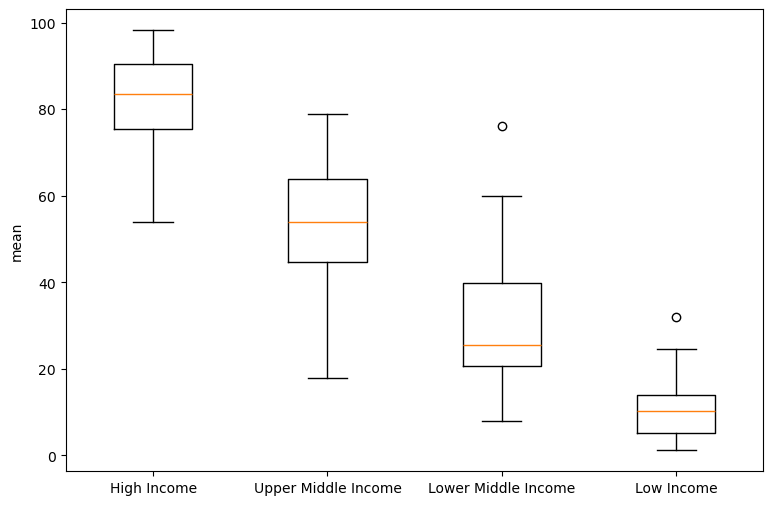

In [5]:
# plotting means to visualize the differences
fig, axs = plt.subplots(1, 1, figsize=(9, 6))
axs.boxplot([high_income['Internet'].dropna(), u_middle_income['Internet'].dropna(), l_middle_income['Internet'].dropna(), low_income['Internet'].dropna()])
axs.set_xticklabels(["High Income", "Upper Middle Income", "Lower Middle Income", "Low Income"]) 
axs.set_ylabel("mean") 
plt.show()

REGRESSION ANALYSIS

In [6]:
# Regression analysis between Internet usage and political stability for the year 2016
# Isolate the data for 2016
data_2016 = wb[wb['Year'] == 2016]
data_2016.head()

,Country Name,Country Code,Region,IsCountry,Income group,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
6,Afghanistan,AFG,South Asia,1,Low income,2016,1.5,-2.671054,NaN,1.055,...,5.262,652230.0,1.852782,NaN,NaN,53.104284,9.502653,21602982.0,114192.0,NaN
16,Albania,ALB,Europe & Central Asia,1,Upper middle income,2016,NaN,0.344645,1.32128,1.088,...,1.551,27400.0,28.802190,NaN,NaN,104.967190,17.590230,3369756.0,248640.0,1.324573e+09
26,Algeria,DZA,Middle East & North Africa,1,Lower middle income,2016,NaN,-1.097526,1.40208,1.044,...,3.051,2381741.0,0.821248,NaN,NaN,16.936908,NaN,47041321.0,3404709.0,3.625092e+10
36,American Samoa,ASM,East Asia & Pacific,1,Upper middle income,2016,NaN,1.193236,NaN,1.060,...,NaN,200.0,86.250000,NaN,NaN,252.240000,NaN,NaN,NaN,NaN
46,Andorra,AND,Europe & Central Asia,1,High income,2016,NaN,1.413419,NaN,1.061,...,NaN,470.0,34.042553,NaN,NaN,154.340426,NaN,76132.0,38694.0,NaN


In [7]:
# Seperate predictors and target variable
clean_data = data_2016[['PoliticalStability', 'Internet']].dropna()

X = clean_data['PoliticalStability']
X = sm.add_constant(X)  # adding a constant for the intercept
y = clean_data['Internet']

# Build OLS regression model
est = sm.OLS(y, X)
est = est.fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:               Internet   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     103.5
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           8.62e-20
Time:                        14:52:56   Log-Likelihood:                -903.39
No. Observations:                 198   AIC:                             1811.
Df Residuals:                     196   BIC:                             1817.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 51.1482      1

In [8]:
# Checking results
est.params

const                 51.148248
PoliticalStability    16.989853
dtype: float64

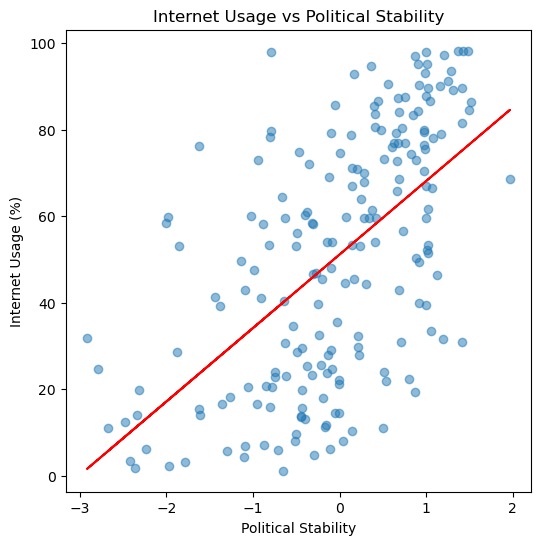

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(clean_data['PoliticalStability'], clean_data['Internet'], alpha=0.5)
ax.plot(clean_data['PoliticalStability'], est.predict(X), color='red')

ax.set_xlabel("Political Stability")
ax.set_ylabel("Internet Usage (%)")
ax.set_title("Internet Usage vs Political Stability")

plt.show()

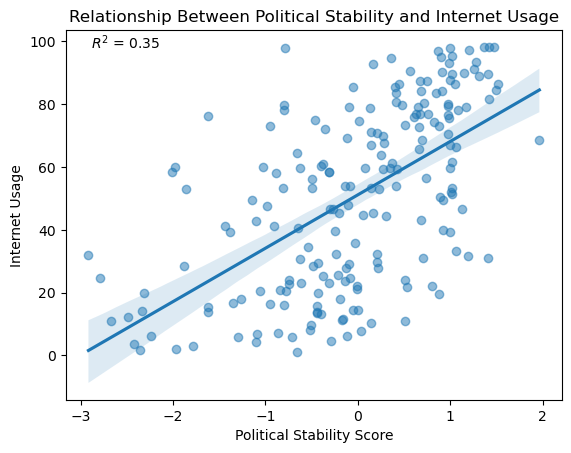

In [ ]:
sns.regplot(x='PoliticalStability', y='Internet', data=clean_data, scatter_kws={'alpha':0.5})

plt.xlabel("Political Stability Score")
plt.ylabel("Internet Usage")
plt.title("Relationship Between Political Stability and Internet Usage")
plt.text(0.05, 0.95, f"$R^2$ = {est.rsquared:.2f}", transform=plt.gca().transAxes)

plt.show()